### DÉTECTION DE FRAUDE DANS LE SECTEUR BANCAIRE (EDA)

**Analyse Exploratoire Intensive des Données de Transactions par Carte de Crédit**
* **Auditoire :** 3 IDSD ID
* **Date :** Janvier 2025

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

#### 1. CHARGEMENT ET APERÇU DES DONNÉES

In [4]:
# Charger les données
df = pd.read_csv('../notebooks/data/fraudTest.csv')

In [5]:
print(f"\n📊 Dimensions du dataset: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"💾 Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


📊 Dimensions du dataset: 300,000 lignes × 23 colonnes
💾 Taille mémoire: 239.46 MB


In [6]:
print("Premières lignes du dataset:")

df.head()

Premières lignes du dataset:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [7]:
print("Informations sur les colonnes:")

print(df.info())

Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             300000 non-null  int64  
 1   trans_date_trans_time  300000 non-null  object 
 2   cc_num                 300000 non-null  int64  
 3   merchant               300000 non-null  object 
 4   category               300000 non-null  object 
 5   amt                    300000 non-null  float64
 6   first                  300000 non-null  object 
 7   last                   300000 non-null  object 
 8   gender                 300000 non-null  object 
 9   street                 300000 non-null  object 
 10  city                   300000 non-null  object 
 11  state                  300000 non-null  object 
 12  zip                    300000 non-null  int64  
 13  lat                    300000 non-null  float64
 14  long 

#### 2. PRÉSENTATION ET DESCRIPTION DÉTAILLÉE DES FEATURES

In [8]:
features_description = {
    'Unnamed: 0': {
        'Type': 'Integer',
        'Description': 'Index de la transaction (identifiant unique)',
        'Utilité': 'Identification et traçabilité des transactions'
    },
    'trans_date_trans_time': {
        'Type': 'Datetime',
        'Description': 'Date et heure exacte de la transaction',
        'Utilité': 'Analyse temporelle, détection de patterns horaires/journaliers'
    },
    'cc_num': {
        'Type': 'Integer',
        'Description': 'Numéro de carte de crédit (anonymisé)',
        'Utilité': 'Identification du client, analyse du comportement par carte'
    },
    'merchant': {
        'Type': 'String',
        'Description': 'Nom du commerçant où la transaction a été effectuée',
        'Utilité': 'Analyse des patterns par commerçant, détection de marchands suspects'
    },
    'category': {
        'Type': 'Categorical',
        'Description': 'Catégorie du commerçant (ex: grocery, gas, entertainment)',
        'Utilité': 'Analyse sectorielle, profils de dépenses par catégorie'
    },
    'amt': {
        'Type': 'Float',
        'Description': 'Montant de la transaction en dollars ($)',
        'Utilité': 'Analyse des montants, détection de transactions anormales'
    },
    'first': {
        'Type': 'String',
        'Description': 'Prénom du titulaire de la carte',
        'Utilité': 'Identification client (avec nom de famille)'
    },
    'last': {
        'Type': 'String',
        'Description': 'Nom de famille du titulaire de la carte',
        'Utilité': 'Identification client (avec prénom)'
    },
    'gender': {
        'Type': 'Categorical',
        'Description': 'Genre du titulaire (M/F)',
        'Utilité': 'Analyse démographique, segmentation'
    },
    'street': {
        'Type': 'String',
        'Description': 'Adresse postale du titulaire',
        'Utilité': 'Localisation géographique précise'
    },
    'city': {
        'Type': 'String',
        'Description': 'Ville de résidence du titulaire',
        'Utilité': 'Analyse géographique, patterns urbains'
    },
    'state': {
        'Type': 'Categorical',
        'Description': 'État de résidence (code à 2 lettres)',
        'Utilité': 'Analyse géographique par état'
    },
    'zip': {
        'Type': 'Integer',
        'Description': 'Code postal de résidence',
        'Utilité': 'Géolocalisation, analyse socio-économique'
    },
    'lat': {
        'Type': 'Float',
        'Description': 'Latitude de la résidence du titulaire',
        'Utilité': 'Géolocalisation précise, calcul de distances'
    },
    'long': {
        'Type': 'Float',
        'Description': 'Longitude de la résidence du titulaire',
        'Utilité': 'Géolocalisation précise, calcul de distances'
    },
    'city_pop': {
        'Type': 'Integer',
        'Description': 'Population de la ville de résidence',
        'Utilité': 'Analyse socio-démographique, contexte urbain/rural'
    },
    'job': {
        'Type': 'String',
        'Description': 'Profession du titulaire de la carte',
        'Utilité': 'Analyse socio-professionnelle, profils de revenus'
    },
    'dob': {
        'Type': 'Date',
        'Description': 'Date de naissance du titulaire',
        'Utilité': 'Calcul de l\'âge, analyse générationnelle'
    },
    'trans_num': {
        'Type': 'String',
        'Description': 'Identifiant unique de la transaction (hash)',
        'Utilité': 'Traçabilité, jointure avec autres tables'
    },
    'unix_time': {
        'Type': 'Integer',
        'Description': 'Timestamp Unix de la transaction',
        'Utilité': 'Calculs temporels, mesure d\'intervalles'
    },
    'merch_lat': {
        'Type': 'Float',
        'Description': 'Latitude du commerçant',
        'Utilité': 'Géolocalisation du commerce, calcul de distance'
    },
    'merch_long': {
        'Type': 'Float',
        'Description': 'Longitude du commerçant',
        'Utilité': 'Géolocalisation du commerce, calcul de distance'
    },
    'is_fraud': {
        'Type': 'Binary (0/1)',
        'Description': 'Variable cible: 1=Fraude, 0=Transaction légitime',
        'Utilité': 'Label pour la modélisation, analyse des patterns frauduleux'
    }
}

In [9]:
for feature, info in features_description.items():
    print(f"\n📌 {feature}")
    print(f"   Type: {info['Type']}")
    print(f"   Description: {info['Description']}")
    print(f"   Utilité: {info['Utilité']}")


📌 Unnamed: 0
   Type: Integer
   Description: Index de la transaction (identifiant unique)
   Utilité: Identification et traçabilité des transactions

📌 trans_date_trans_time
   Type: Datetime
   Description: Date et heure exacte de la transaction
   Utilité: Analyse temporelle, détection de patterns horaires/journaliers

📌 cc_num
   Type: Integer
   Description: Numéro de carte de crédit (anonymisé)
   Utilité: Identification du client, analyse du comportement par carte

📌 merchant
   Type: String
   Description: Nom du commerçant où la transaction a été effectuée
   Utilité: Analyse des patterns par commerçant, détection de marchands suspects

📌 category
   Type: Categorical
   Description: Catégorie du commerçant (ex: grocery, gas, entertainment)
   Utilité: Analyse sectorielle, profils de dépenses par catégorie

📌 amt
   Type: Float
   Description: Montant de la transaction en dollars ($)
   Utilité: Analyse des montants, détection de transactions anormales

📌 first
   Type: Strin

#### 3. STATISTIQUES DESCRIPTIVES GLOBALES

In [10]:
print("Variables numériques:")

df.describe().T

Variables numériques:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,300000.0,1.499995e+05,8.660268e+04,0.000000e+00,7.499975e+04,1.499995e+05,2.249992e+05,2.999990e+05
cc_num,300000.0,4.179979e+17,1.310088e+18,6.041621e+10,1.800429e+14,3.520550e+15,4.635331e+15,4.992346e+18
amt,300000.0,6.954821e+01,1.476406e+02,1.000000e+00,9.640000e+00,4.736000e+01,8.309000e+01,1.683708e+04
zip,300000.0,4.881577e+04,2.685667e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.201100e+04,9.978300e+04
lat,300000.0,3.854518e+01,5.066608e+00,2.002710e+01,3.466890e+01,3.937160e+01,4.194040e+01,6.568990e+01
long,300000.0,-9.021719e+01,1.372014e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.017520e+01,-6.795030e+01
city_pop,300000.0,8.840305e+04,2.996303e+05,2.300000e+01,7.410000e+02,2.408000e+03,1.968500e+04,2.906700e+06
unix_time,300000.0,1.376443e+09,2.783122e+06,1.371817e+09,1.374066e+09,1.376294e+09,1.378715e+09,1.381587e+09
merch_lat,300000.0,3.854446e+01,5.102371e+00,1.903953e+01,3.475793e+01,3.938170e+01,4.196250e+01,6.666936e+01
merch_long,300000.0,-9.021717e+01,1.373244e+01,-1.666716e+02,-9.688952e+01,-8.743563e+01,-8.025857e+01,-6.695203e+01


In [11]:
df.amt.quantile(0.99)

529.4204000000003

In [12]:
df[df.amt == df.amt.max()]

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
251793,251793,2020-09-21 12:02:00,3566094707272327,fraud_Johnston-Casper,travel,16837.08,Kristina,Stewart,F,47029 Jimmy Tunnel Apt. 106,Newhall,CA,91321,34.3795,-118.523,34882,Health physicist,1971-04-25,ba246b12f894ab083706e72f9d90ad15,1379764920,35.111725,-118.128435,0


In [13]:
print("Variables catégorielles:")

categorical_cols = ['gender', 'category', 'state']
for col in categorical_cols:
    print(df[col].value_counts().head(10))
    print()

Variables catégorielles:
gender
F    164447
M    135553
Name: count, dtype: int64

category
gas_transport     30503
grocery_pos       28517
home              27972
shopping_pos      26647
kids_pets         26298
shopping_net      22726
entertainment     21614
food_dining       21400
personal_care     21107
health_fitness    19812
Name: count, dtype: int64

state
TX    21814
NY    19558
PA    18464
CA    12923
OH    10797
MI    10672
IL    10110
FL     9834
AL     9493
MO     8975
Name: count, dtype: int64



#### 4. ANALYSE DE LA VARIABLE CIBLE (FRAUDE)

In [14]:
fraud_counts = df['is_fraud'].value_counts()
fraud_percentage = df['is_fraud'].value_counts(normalize=True) * 100

In [15]:
print(f"\n🎯 Distribution des fraudes:")
print(f"   Transactions légitimes: {fraud_counts[0]:,} ({fraud_percentage[0]:.2f}%)")
print(f"   Transactions frauduleuses: {fraud_counts[1]:,} ({fraud_percentage[1]:.2f}%)")
print(f"   Ratio fraude/légitime: 1:{int(fraud_counts[0]/fraud_counts[1])}")
print(f"\n⚠️  Dataset FORTEMENT DÉSÉQUILIBRÉ - Techniques de rééquilibrage nécessaires!")


🎯 Distribution des fraudes:
   Transactions légitimes: 298,623 (99.54%)
   Transactions frauduleuses: 1,377 (0.46%)
   Ratio fraude/légitime: 1:216

⚠️  Dataset FORTEMENT DÉSÉQUILIBRÉ - Techniques de rééquilibrage nécessaires!


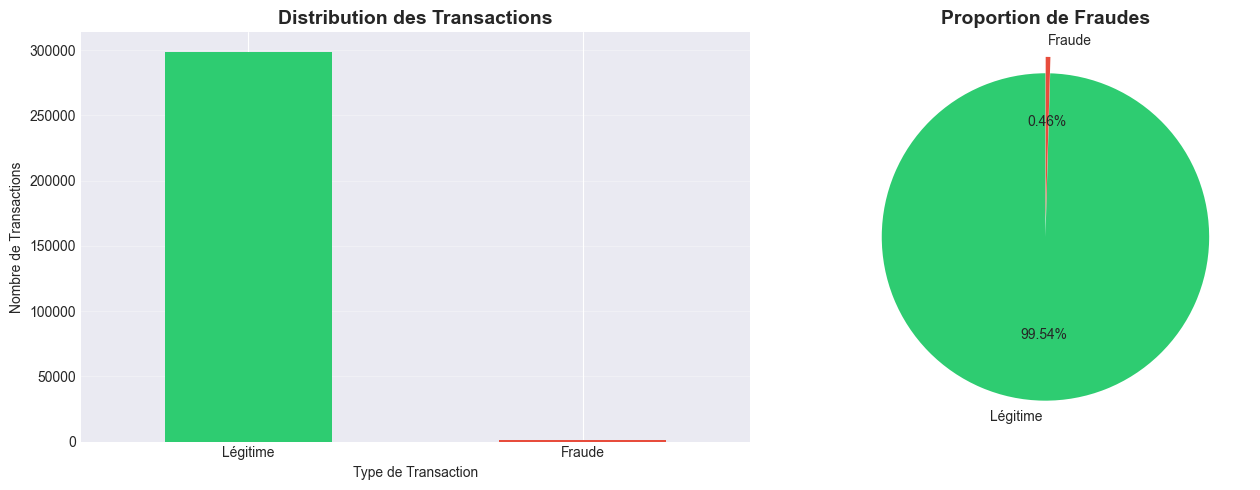

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Comptage
df['is_fraud'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution des Transactions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Type de Transaction')
axes[0].set_ylabel('Nombre de Transactions')
axes[0].set_xticklabels(['Légitime', 'Fraude'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Graphique 2: Pourcentage
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(fraud_counts, labels=['Légitime', 'Fraude'], autopct='%1.2f%%',
            colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Proportion de Fraudes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./png/fraud_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

#### 5. ANALYSE DES VALEURS MANQUANTES

In [17]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

In [18]:
missing_df = pd.DataFrame({
    'Colonnes': missing_values.index,
    'Valeurs Manquantes': missing_values.values,
    'Pourcentage (%)': missing_percentage.values
})

In [19]:
missing_df = missing_df[missing_df['Valeurs Manquantes'] > 0].sort_values('Valeurs Manquantes', ascending=False)

In [20]:
if len(missing_df) > 0:
    print("\n⚠️  Valeurs manquantes détectées:")
    print(missing_df.to_string(index=False))
else:
    print("\n✅ Aucune valeur manquante détectée dans le dataset!")


✅ Aucune valeur manquante détectée dans le dataset!


#### 6. FEATURE ENGINEERING - CRÉATION DE NOUVELLES VARIABLES

In [21]:
# Conversion de la date
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Unnamed: 0             300000 non-null  int64         
 1   trans_date_trans_time  300000 non-null  datetime64[ns]
 2   cc_num                 300000 non-null  int64         
 3   merchant               300000 non-null  object        
 4   category               300000 non-null  object        
 5   amt                    300000 non-null  float64       
 6   first                  300000 non-null  object        
 7   last                   300000 non-null  object        
 8   gender                 300000 non-null  object        
 9   street                 300000 non-null  object        
 10  city                   300000 non-null  object        
 11  state                  300000 non-null  object        
 12  zip                    300000 non-null  int6

In [23]:
# Extraction de features temporelles
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
df['year'] = df['trans_date_trans_time'].dt.year
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [24]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day_of_week,day,month,year,is_weekend
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,6,21,6,2020,1
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,6,21,6,2020,1
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,6,21,6,2020,1
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,6,21,6,2020,1
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,6,21,6,2020,1


In [25]:
# Période de la journée
def get_time_period(hour):
    if 0 <= hour < 6:
        return 'Nuit (0h-6h)'
    elif 6 <= hour < 12:
        return 'Matin (6h-12h)'
    elif 12 <= hour < 18:
        return 'Après-midi (12h-18h)'
    else:
        return 'Soirée (18h-24h)'

df['time_period'] = df['hour'].apply(get_time_period)

In [26]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day_of_week,day,month,year,is_weekend,time_period
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,6,21,6,2020,1,Après-midi (12h-18h)
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,6,21,6,2020,1,Après-midi (12h-18h)
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,6,21,6,2020,1,Après-midi (12h-18h)
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,6,21,6,2020,1,Après-midi (12h-18h)
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,6,21,6,2020,1,Après-midi (12h-18h)


In [27]:
# Âge du client
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25

In [28]:
# Catégorie d'âge
def get_age_category(age):
    if age < 25:
        return '18-25 ans'
    elif age < 35:
        return '25-35 ans'
    elif age < 45:
        return '35-45 ans'
    elif age < 55:
        return '45-55 ans'
    elif age < 65:
        return '55-65 ans'
    else:
        return '65+ ans'

df['age_category'] = df['age'].apply(get_age_category)

In [29]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day_of_week,day,month,year,is_weekend,time_period,age,age_category
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,6,21,6,2020,1,Après-midi (12h-18h),52.257358,45-55 ans
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,6,21,6,2020,1,Après-midi (12h-18h),30.425736,25-35 ans
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,6,21,6,2020,1,Après-midi (12h-18h),49.667351,45-55 ans
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,6,21,6,2020,1,Après-midi (12h-18h),32.908966,25-35 ans
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,6,21,6,2020,1,Après-midi (12h-18h),64.960986,55-65 ans


In [30]:
# Distance entre client et commerçant (formule de Haversine simplifiée)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Rayon de la Terre en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    # formule de Heversine
    c = 2 * np.arcsin(np.sqrt(a))
    # angle central entre les deux points (en radians)
    return R * c # distance

df['distance_km'] = haversine_distance(df['lat'], df['long'], 
                                        df['merch_lat'], df['merch_long'])

In [31]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day_of_week,day,month,year,is_weekend,time_period,age,age_category,distance_km
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,6,21,6,2020,1,Après-midi (12h-18h),52.257358,45-55 ans,24.561462
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,6,21,6,2020,1,Après-midi (12h-18h),30.425736,25-35 ans,104.925092
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,6,21,6,2020,1,Après-midi (12h-18h),49.667351,45-55 ans,59.080078
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,6,21,6,2020,1,Après-midi (12h-18h),32.908966,25-35 ans,27.698567
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,6,21,6,2020,1,Après-midi (12h-18h),64.960986,55-65 ans,104.335106


In [32]:
# Catégorie de distance
def get_distance_category(dist):
    if dist < 5:
        return 'Très proche (<5km)'
    elif dist < 20:
        return 'Proche (5-20km)'
    elif dist < 100:
        return 'Moyen (20-100km)'
    else:
        return 'Lointain (>100km)'

df['distance_category'] = df['distance_km'].apply(get_distance_category)

In [33]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day_of_week,day,month,year,is_weekend,time_period,age,age_category,distance_km,distance_category
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,6,21,6,2020,1,Après-midi (12h-18h),52.257358,45-55 ans,24.561462,Moyen (20-100km)
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,6,21,6,2020,1,Après-midi (12h-18h),30.425736,25-35 ans,104.925092,Lointain (>100km)
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,6,21,6,2020,1,Après-midi (12h-18h),49.667351,45-55 ans,59.080078,Moyen (20-100km)
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,6,21,6,2020,1,Après-midi (12h-18h),32.908966,25-35 ans,27.698567,Moyen (20-100km)
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,6,21,6,2020,1,Après-midi (12h-18h),64.960986,55-65 ans,104.335106,Lointain (>100km)


In [34]:
# Catégorie de montant
def get_amount_category(amt):
    if amt < 10:
        return 'Micro (<10$)'
    elif amt < 50:
        return 'Petit (10-50$)'
    elif amt < 100:
        return 'Moyen (50-100$)'
    elif amt < 500:
        return 'Élevé (100-500$)'
    else:
        return 'Très élevé (>500$)'

df['amount_category'] = df['amt'].apply(get_amount_category)

In [35]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day_of_week,day,month,year,is_weekend,time_period,age,age_category,distance_km,distance_category,amount_category
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,6,21,6,2020,1,Après-midi (12h-18h),52.257358,45-55 ans,24.561462,Moyen (20-100km),Micro (<10$)
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,6,21,6,2020,1,Après-midi (12h-18h),30.425736,25-35 ans,104.925092,Lointain (>100km),Petit (10-50$)
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,6,21,6,2020,1,Après-midi (12h-18h),49.667351,45-55 ans,59.080078,Moyen (20-100km),Petit (10-50$)
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,6,21,6,2020,1,Après-midi (12h-18h),32.908966,25-35 ans,27.698567,Moyen (20-100km),Moyen (50-100$)
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,6,21,6,2020,1,Après-midi (12h-18h),64.960986,55-65 ans,104.335106,Lointain (>100km),Micro (<10$)


In [36]:
print("\n✅ Nouvelles features créées:")
new_features = ['hour', 'day_of_week', 'month', 'is_weekend', 'time_period', 
                'age', 'age_category', 'distance_km', 'distance_category', 'amount_category']
for feat in new_features:
    print(f"   • {feat}")


✅ Nouvelles features créées:
   • hour
   • day_of_week
   • month
   • is_weekend
   • time_period
   • age
   • age_category
   • distance_km
   • distance_category
   • amount_category


#### 7. ANALYSE DES MONTANTS DE TRANSACTIONS

In [37]:
print("Statistiques des montants par type:")

df.groupby('is_fraud')['amt'].describe()

Statistiques des montants par type:


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,298623.0,67.428797,142.135549,1.00,9.60,47.18,82.63,16837.08
1,1377.0,529.173965,394.497346,1.78,136.93,379.30,913.68,1320.92


In [38]:
fraud_amounts = df[df['is_fraud'] == 1]['amt']
legit_amounts = df[df['is_fraud'] == 0]['amt']

In [39]:
print(f"\n💰 Montant moyen:")
print(f"   Transactions légitimes: ${legit_amounts.mean():.2f}")
print(f"   Transactions frauduleuses: ${fraud_amounts.mean():.2f}")
print(f"   Différence: ${abs(fraud_amounts.mean() - legit_amounts.mean()):.2f}")


💰 Montant moyen:
   Transactions légitimes: $67.43
   Transactions frauduleuses: $529.17
   Différence: $461.75


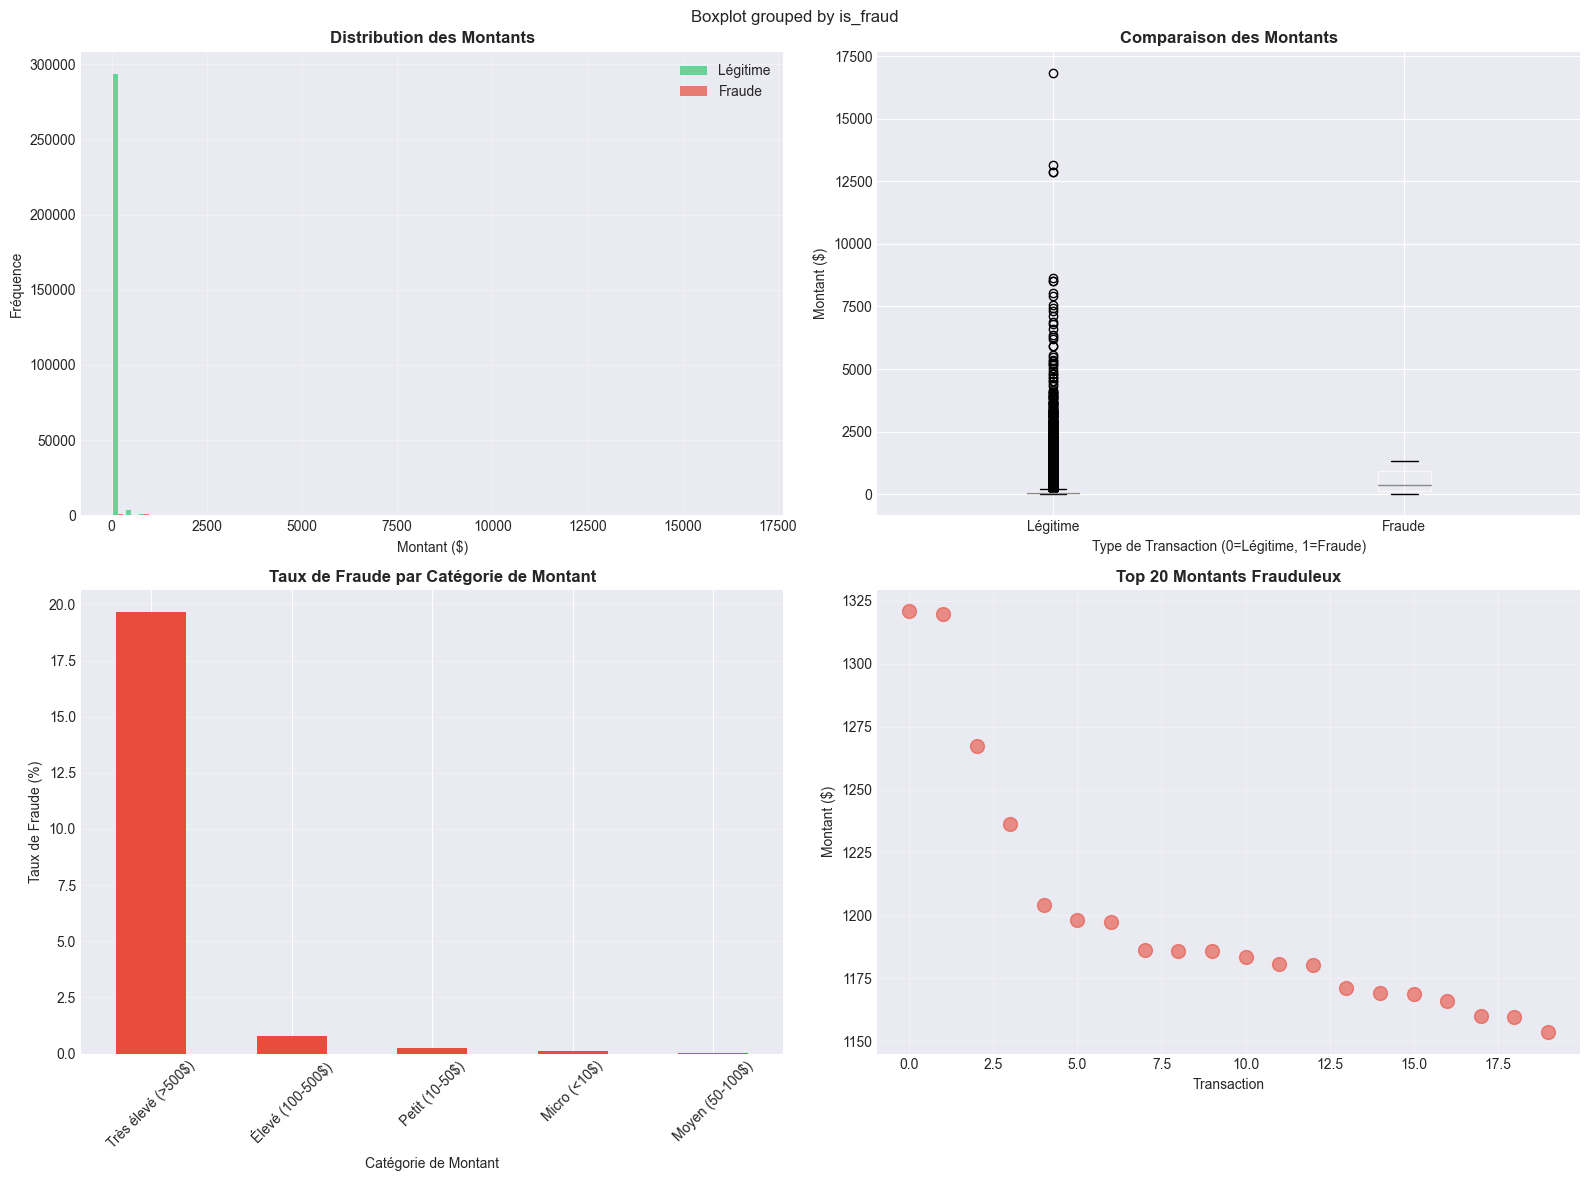

In [40]:
# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution des montants (légitime vs fraude)
axes[0, 0].hist([legit_amounts, fraud_amounts], bins=50, label=['Légitime', 'Fraude'],
                color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0, 0].set_xlabel('Montant ($)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution des Montants', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Boxplot comparatif
df.boxplot(column='amt', by='is_fraud', ax=axes[0, 1])
axes[0, 1].set_xlabel('Type de Transaction (0=Légitime, 1=Fraude)')
axes[0, 1].set_ylabel('Montant ($)')
axes[0, 1].set_title('Comparaison des Montants', fontweight='bold')
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Légitime', 'Fraude'])

# Distribution par catégorie de montant
amount_fraud = df.groupby('amount_category')['is_fraud'].agg(['sum', 'count', 'mean'])
amount_fraud['fraud_rate'] = amount_fraud['mean'] * 100
amount_fraud = amount_fraud.sort_values('fraud_rate', ascending=False)

amount_fraud['fraud_rate'].plot(kind='bar', ax=axes[1, 0], color='#e74c3c')
axes[1, 0].set_xlabel('Catégorie de Montant')
axes[1, 0].set_ylabel('Taux de Fraude (%)')
axes[1, 0].set_title('Taux de Fraude par Catégorie de Montant', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Top montants frauduleux
top_fraud_amounts = df[df['is_fraud'] == 1].nlargest(20, 'amt')
axes[1, 1].scatter(range(len(top_fraud_amounts)), top_fraud_amounts['amt'], 
                   color='#e74c3c', s=100, alpha=0.6)
axes[1, 1].set_xlabel('Transaction')
axes[1, 1].set_ylabel('Montant ($)')
axes[1, 1].set_title('Top 20 Montants Frauduleux', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./png/amount_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

#### 8. ANALYSE TEMPORELLE

In [41]:
# Fraudes par heure
print("Distribution horaire des fraudes:")
hourly_fraud = df.groupby('hour')['is_fraud'].agg(['sum', 'count', 'mean'])
hourly_fraud['fraud_rate'] = hourly_fraud['mean'] * 100
print(hourly_fraud.sort_values('fraud_rate', ascending=False).head(10))

Distribution horaire des fraudes:
      sum  count      mean  fraud_rate
hour                                  
22    357  15377  0.023216    2.321649
23    351  15574  0.022538    2.253756
3     122   9811  0.012435    1.243502
0     118   9820  0.012016    1.201629
2     111   9855  0.011263    1.126332
1     107   9974  0.010728    1.072789
18     19  15065  0.001261    0.126120
7      12   9813  0.001223    0.122287
11     12   9841  0.001219    0.121939
9      11   9731  0.001130    0.113041


In [42]:
# Fraudes par jour de la semaine
print("\n" + "-" * 80)
print("Distribution hebdomadaire des fraudes:")
print("-" * 80)
days_map = {0: 'Lundi', 1: 'Mardi', 2: 'Mercredi', 3: 'Jeudi', 
            4: 'Vendredi', 5: 'Samedi', 6: 'Dimanche'}
daily_fraud = df.groupby('day_of_week')['is_fraud'].agg(['sum', 'count', 'mean'])
daily_fraud['fraud_rate'] = daily_fraud['mean'] * 100
daily_fraud.index = daily_fraud.index.map(days_map)
print(daily_fraud)


--------------------------------------------------------------------------------
Distribution hebdomadaire des fraudes:
--------------------------------------------------------------------------------
             sum  count      mean  fraud_rate
day_of_week                                  
Lundi        230  62043  0.003707    0.370711
Mardi        230  57762  0.003982    0.398186
Mercredi     157  27307  0.005749    0.574944
Jeudi        182  31077  0.005856    0.585642
Vendredi     174  34708  0.005013    0.501325
Samedi       155  34511  0.004491    0.449132
Dimanche     249  52592  0.004735    0.473456


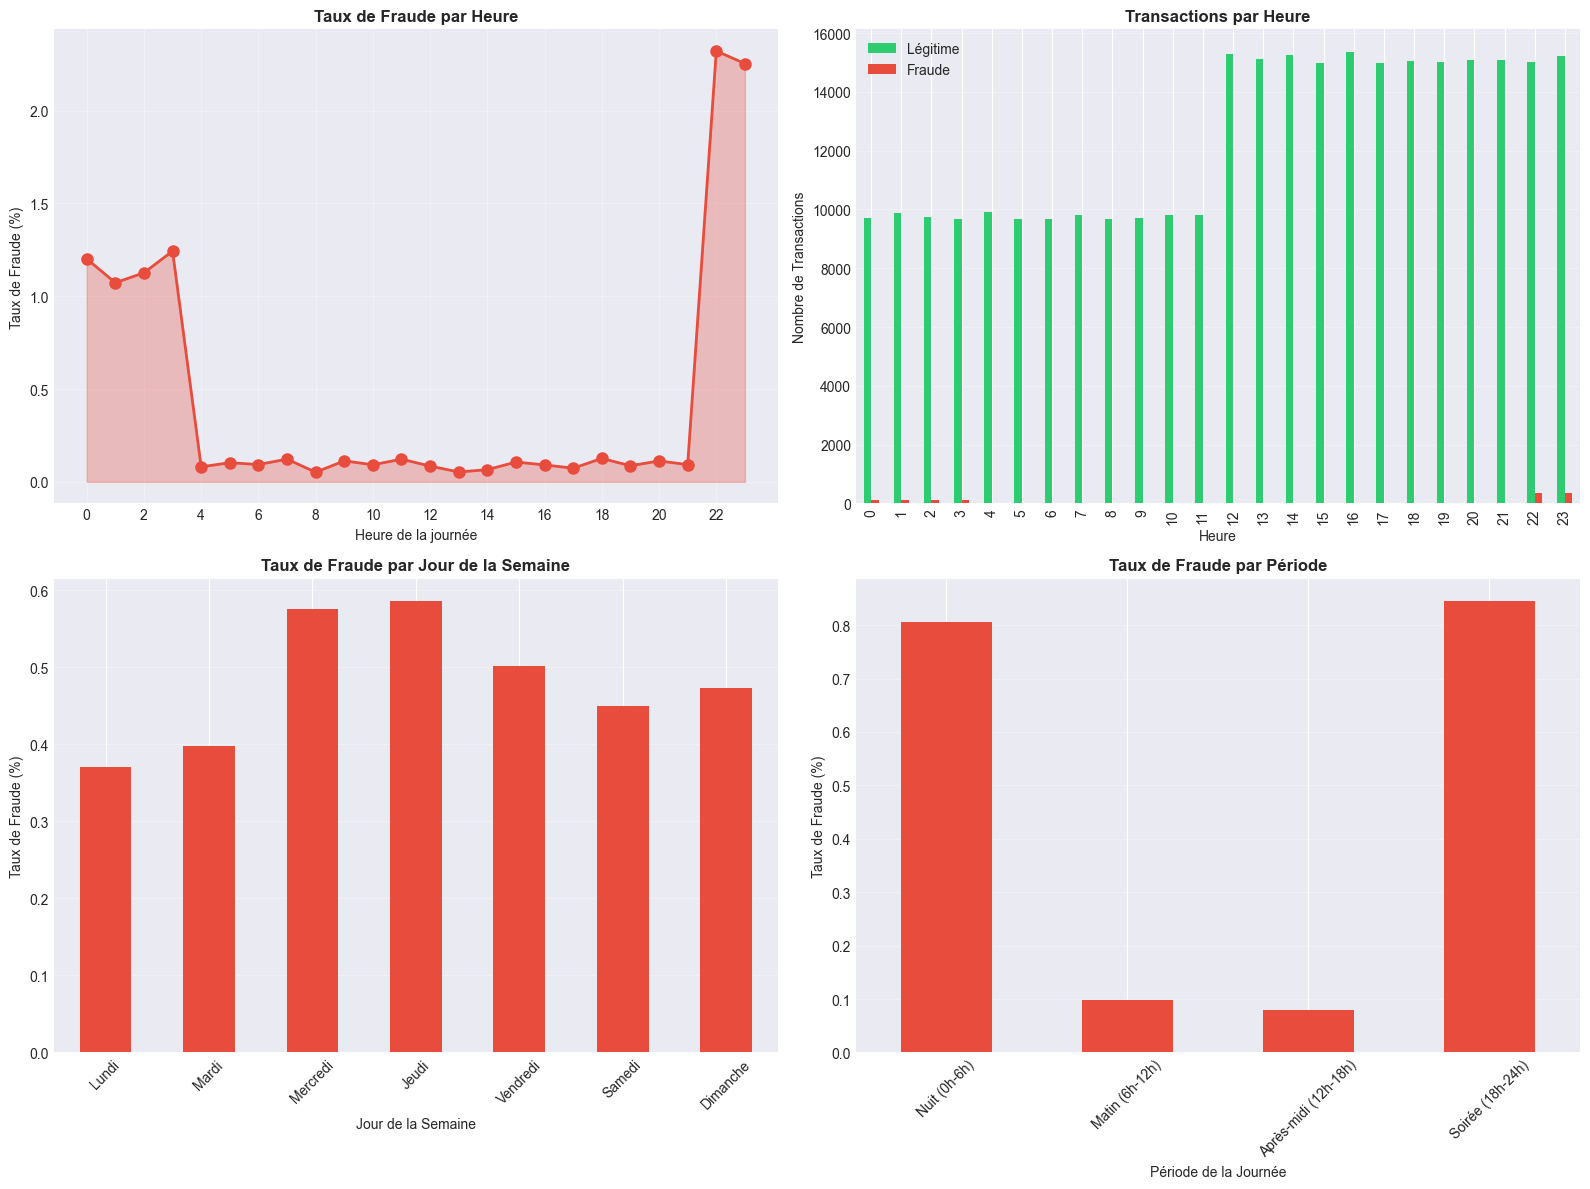

In [43]:
# Visualisations temporelles
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Fraudes par heure
axes[0, 0].plot(hourly_fraud.index, hourly_fraud['fraud_rate'], 
                marker='o', linewidth=2, markersize=8, color='#e74c3c')
axes[0, 0].fill_between(hourly_fraud.index, hourly_fraud['fraud_rate'], alpha=0.3, color='#e74c3c')
axes[0, 0].set_xlabel('Heure de la journée')
axes[0, 0].set_ylabel('Taux de Fraude (%)')
axes[0, 0].set_title('Taux de Fraude par Heure', fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 2))

# Transactions par heure (légitime vs fraude)
hour_counts = df.groupby(['hour', 'is_fraud']).size().unstack(fill_value=0)
hour_counts.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_xlabel('Heure')
axes[0, 1].set_ylabel('Nombre de Transactions')
axes[0, 1].set_title('Transactions par Heure', fontweight='bold')
axes[0, 1].legend(['Légitime', 'Fraude'])
axes[0, 1].grid(axis='y', alpha=0.3)

# Fraudes par jour de la semaine
daily_fraud['fraud_rate'].plot(kind='bar', ax=axes[1, 0], color='#e74c3c')
axes[1, 0].set_xlabel('Jour de la Semaine')
axes[1, 0].set_ylabel('Taux de Fraude (%)')
axes[1, 0].set_title('Taux de Fraude par Jour de la Semaine', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Fraudes par période de la journée
period_fraud = df.groupby('time_period')['is_fraud'].agg(['sum', 'count', 'mean'])
period_fraud['fraud_rate'] = period_fraud['mean'] * 100
period_order = ['Nuit (0h-6h)', 'Matin (6h-12h)', 'Après-midi (12h-18h)', 'Soirée (18h-24h)']
period_fraud = period_fraud.reindex(period_order)
period_fraud['fraud_rate'].plot(kind='bar', ax=axes[1, 1], color='#e74c3c')
axes[1, 1].set_xlabel('Période de la Journée')
axes[1, 1].set_ylabel('Taux de Fraude (%)')
axes[1, 1].set_title('Taux de Fraude par Période', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./png/temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


#### 9. ANALYSE PAR CATÉGORIE DE COMMERÇANTS

In [44]:
category_fraud = df.groupby('category')['is_fraud'].agg(['sum', 'count', 'mean'])
category_fraud['fraud_rate'] = category_fraud['mean'] * 100
category_fraud = category_fraud.sort_values('fraud_rate', ascending=False)

In [45]:
print("Taux de fraude par catégorie:")

category_fraud

Taux de fraude par catégorie:


,sum,count,mean,fraud_rate
category,,,,
shopping_net,324,22726,0.014257,1.425680
misc_net,167,14763,0.011312,1.131206
grocery_pos,300,28517,0.010520,1.052004
shopping_pos,137,26647,0.005141,0.514129
travel,28,9502,0.002947,0.294675
gas_transport,83,30503,0.002721,0.272104
misc_pos,51,18773,0.002717,0.271667
grocery_net,25,10366,0.002412,0.241173
personal_care,50,21107,0.002369,0.236888


In [46]:
print(f"\n⚠️  Catégories les plus risquées:")
for idx, (cat, row) in enumerate(category_fraud.head(5).iterrows(), 1):
    print(f"   {idx}. {cat}: {row['fraud_rate']:.2f}% ({int(row['sum'])} fraudes sur {int(row['count'])} transactions)")


⚠️  Catégories les plus risquées:
   1. shopping_net: 1.43% (324 fraudes sur 22726 transactions)
   2. misc_net: 1.13% (167 fraudes sur 14763 transactions)
   3. grocery_pos: 1.05% (300 fraudes sur 28517 transactions)
   4. shopping_pos: 0.51% (137 fraudes sur 26647 transactions)
   5. travel: 0.29% (28 fraudes sur 9502 transactions)


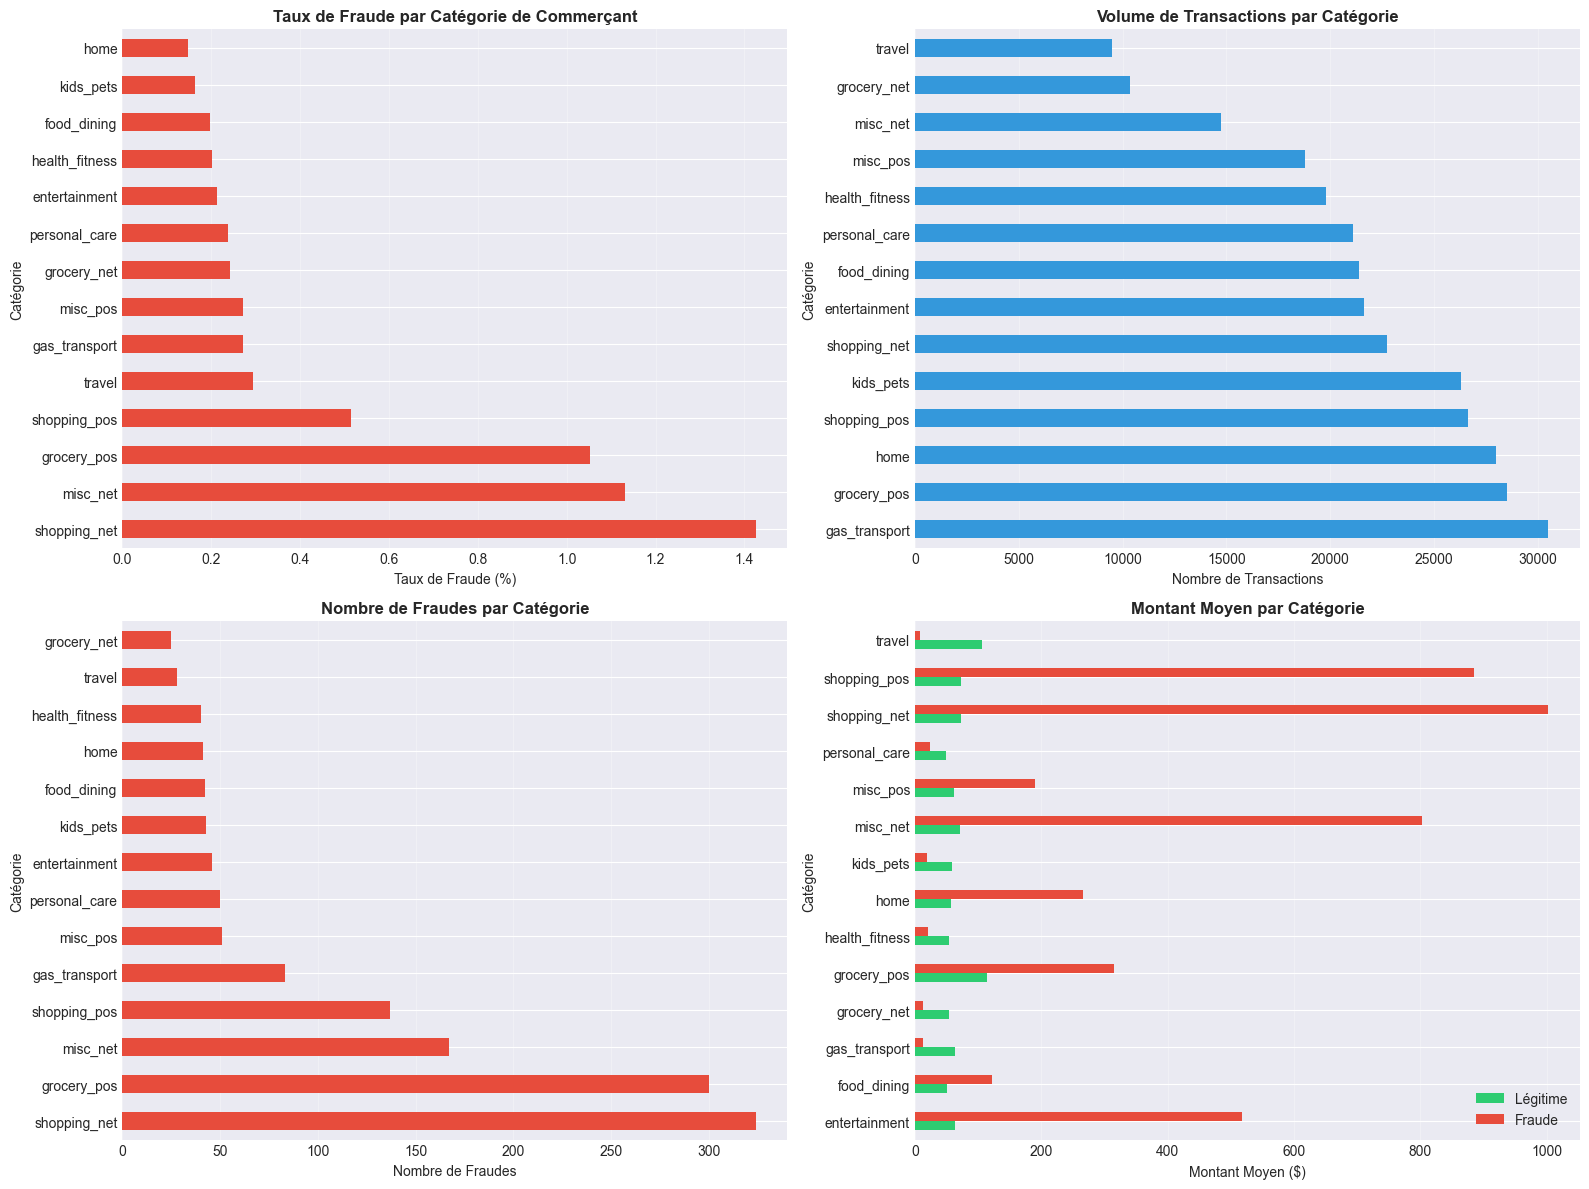

In [47]:
# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Taux de fraude par catégorie
category_fraud['fraud_rate'].plot(kind='barh', ax=axes[0, 0], color='#e74c3c')
axes[0, 0].set_xlabel('Taux de Fraude (%)')
axes[0, 0].set_ylabel('Catégorie')
axes[0, 0].set_title('Taux de Fraude par Catégorie de Commerçant', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Nombre de transactions par catégorie
category_fraud['count'].sort_values(ascending=False).plot(kind='barh', ax=axes[0, 1], color='#3498db')
axes[0, 1].set_xlabel('Nombre de Transactions')
axes[0, 1].set_ylabel('Catégorie')
axes[0, 1].set_title('Volume de Transactions par Catégorie', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Nombre de fraudes par catégorie
category_fraud['sum'].sort_values(ascending=False).plot(kind='barh', ax=axes[1, 0], color='#e74c3c')
axes[1, 0].set_xlabel('Nombre de Fraudes')
axes[1, 0].set_ylabel('Catégorie')
axes[1, 0].set_title('Nombre de Fraudes par Catégorie', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Montant moyen par catégorie et type de transaction
category_amount = df.groupby(['category', 'is_fraud'])['amt'].mean().unstack(fill_value=0)
category_amount.plot(kind='barh', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_xlabel('Montant Moyen ($)')
axes[1, 1].set_ylabel('Catégorie')
axes[1, 1].set_title('Montant Moyen par Catégorie', fontweight='bold')
axes[1, 1].legend(['Légitime', 'Fraude'])
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./png/category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

#### 10. ANALYSE GÉOGRAPHIQUE

In [48]:
# Fraudes par état
state_fraud = df.groupby('state')['is_fraud'].agg(['sum', 'count', 'mean'])
state_fraud['fraud_rate'] = state_fraud['mean'] * 100
state_fraud = state_fraud.sort_values('fraud_rate', ascending=False)

In [49]:
print("Top 15 états avec le plus haut taux de fraude:")

print(state_fraud.head(15))

Top 15 états avec le plus haut taux de fraude:
       sum  count      mean  fraud_rate
state                                  
HI       9    585  0.015385    1.538462
CT      26   1779  0.014615    1.461495
NM      37   3803  0.009729    0.972916
MT      26   2706  0.009608    0.960828
KY      55   6647  0.008274    0.827441
GA      49   6155  0.007961    0.796101
ND      27   3477  0.007765    0.776531
MN      52   7339  0.007085    0.708543
IN      44   6475  0.006795    0.679537
NC      46   6870  0.006696    0.669578
OR      28   4217  0.006640    0.663979
WI      44   6711  0.006556    0.655640
NE      36   5582  0.006449    0.644930
MO      57   8975  0.006351    0.635097
NY     124  19558  0.006340    0.634012


In [50]:
# Analyse de la distance
print("Statistiques de distance (client-commerçant):")

print(df.groupby('is_fraud')['distance_km'].describe())

Statistiques de distance (client-commerçant):
             count       mean        std       min        25%        50%  \
is_fraud                                                                   
0         298623.0  76.147396  29.105891  0.123883  55.356615  78.244587   
1           1377.0  75.970114  28.865382  3.839619  54.806553  78.613752   

                75%         max  
is_fraud                         
0         98.544407  150.922504  
1         98.070370  142.492992  


In [51]:
distance_fraud = df.groupby('distance_category')['is_fraud'].agg(['sum', 'count', 'mean'])
distance_fraud['fraud_rate'] = distance_fraud['mean'] * 100
print("\n" + "-" * 80)
print("Taux de fraude par catégorie de distance:")
print("-" * 80)
print(distance_fraud)


--------------------------------------------------------------------------------
Taux de fraude par catégorie de distance:
--------------------------------------------------------------------------------
                     sum   count      mean  fraud_rate
distance_category                                     
Lointain (>100km)    315   70204  0.004487    0.448692
Moyen (20-100km)    1021  220020  0.004640    0.464049
Proche (5-20km)       38    9167  0.004145    0.414530
Très proche (<5km)     3     609  0.004926    0.492611


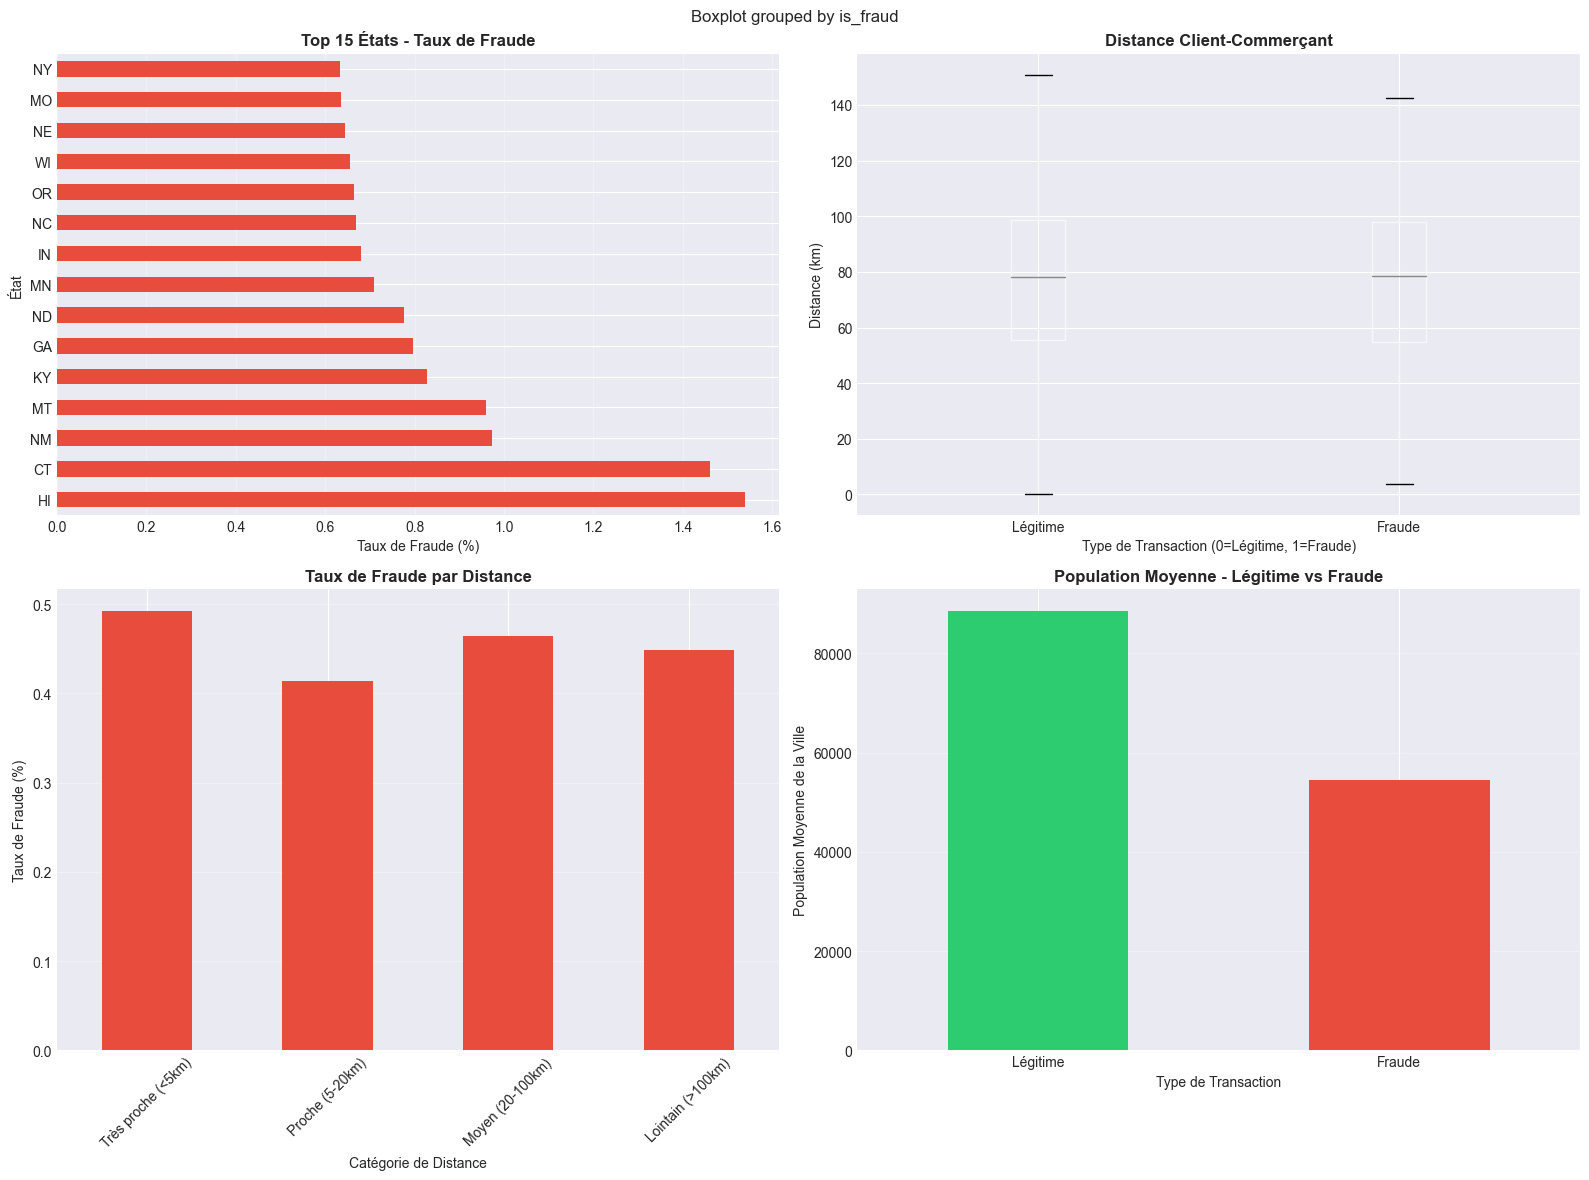

In [52]:
# Visualisations géographiques
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top états par taux de fraude
state_fraud.head(15)['fraud_rate'].plot(kind='barh', ax=axes[0, 0], color='#e74c3c')
axes[0, 0].set_xlabel('Taux de Fraude (%)')
axes[0, 0].set_ylabel('État')
axes[0, 0].set_title('Top 15 États - Taux de Fraude', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Distribution de la distance
df.boxplot(column='distance_km', by='is_fraud', ax=axes[0, 1])
axes[0, 1].set_xlabel('Type de Transaction (0=Légitime, 1=Fraude)')
axes[0, 1].set_ylabel('Distance (km)')
axes[0, 1].set_title('Distance Client-Commerçant', fontweight='bold')
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Légitime', 'Fraude'])

# Taux de fraude par catégorie de distance
distance_order = ['Très proche (<5km)', 'Proche (5-20km)', 'Moyen (20-100km)', 'Lointain (>100km)']
distance_fraud_ordered = distance_fraud.reindex(distance_order)
distance_fraud_ordered['fraud_rate'].plot(kind='bar', ax=axes[1, 0], color='#e74c3c')
axes[1, 0].set_xlabel('Catégorie de Distance')
axes[1, 0].set_ylabel('Taux de Fraude (%)')
axes[1, 0].set_title('Taux de Fraude par Distance', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Population de la ville vs fraude
city_pop_fraud = df.groupby('is_fraud')['city_pop'].mean()
city_pop_fraud.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_xlabel('Type de Transaction')
axes[1, 1].set_ylabel('Population Moyenne de la Ville')
axes[1, 1].set_title('Population Moyenne - Légitime vs Fraude', fontweight='bold')
axes[1, 1].set_xticklabels(['Légitime', 'Fraude'], rotation=0)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./png/geographic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

La 4ème figure compare la population moyenne des villes d’origine des transactions légitimes vs frauduleuses.

➡️ La barre Fraude est plus haute, cela veut dire que les fraudes ont tendance à se produire dans des villes plus grandes en moyenne.

#### 11. ANALYSE DÉMOGRAPHIQUE

In [53]:
# Genre
gender_fraud = df.groupby('gender')['is_fraud'].agg(['sum', 'count', 'mean'])
gender_fraud['fraud_rate'] = gender_fraud['mean'] * 100

print("Fraude par genre:")

print(gender_fraud)

Fraude par genre:
        sum   count      mean  fraud_rate
gender                                   
F       761  164447  0.004628    0.462763
M       616  135553  0.004544    0.454435


In [54]:
# Âge
age_fraud = df.groupby('age_category')['is_fraud'].agg(['sum', 'count', 'mean'])
age_fraud['fraud_rate'] = age_fraud['mean'] * 100
age_order = ['18-25 ans', '25-35 ans', '35-45 ans', '45-55 ans', '55-65 ans', '65+ ans']
age_fraud = age_fraud.reindex(age_order)

print("Fraude par catégorie d'âge:")

print(age_fraud)

Fraude par catégorie d'âge:
              sum  count      mean  fraud_rate
age_category                                  
18-25 ans      68  25885  0.002627    0.262700
25-35 ans     305  61045  0.004996    0.499631
35-45 ans     245  64720  0.003786    0.378554
45-55 ans     273  62234  0.004387    0.438667
55-65 ans     220  37061  0.005936    0.593616
65+ ans       266  49055  0.005422    0.542248


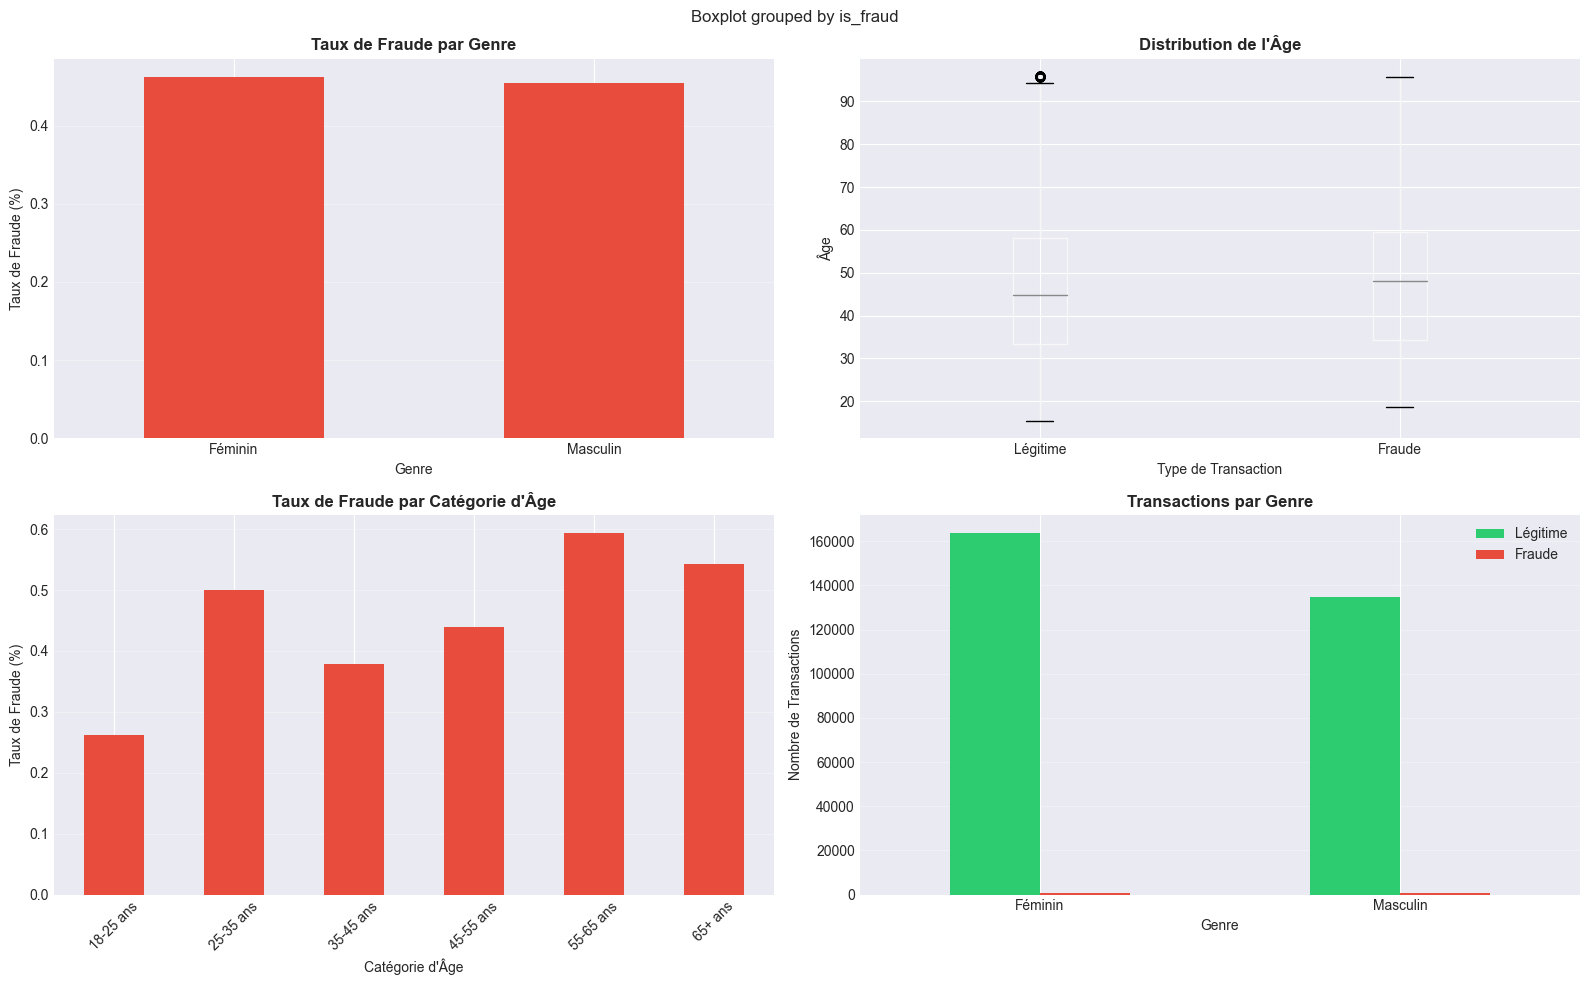

In [55]:
# Visualisations démographiques
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Genre
gender_fraud['fraud_rate'].plot(kind='bar', ax=axes[0, 0], color='#e74c3c')
axes[0, 0].set_xlabel('Genre')
axes[0, 0].set_ylabel('Taux de Fraude (%)')
axes[0, 0].set_title('Taux de Fraude par Genre', fontweight='bold')
axes[0, 0].set_xticklabels(['Féminin', 'Masculin'], rotation=0)
axes[0, 0].grid(axis='y', alpha=0.3)

# Distribution de l'âge
df.boxplot(column='age', by='is_fraud', ax=axes[0, 1])
axes[0, 1].set_xlabel('Type de Transaction')
axes[0, 1].set_ylabel('Âge')
axes[0, 1].set_title('Distribution de l\'Âge', fontweight='bold')
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Légitime', 'Fraude'])

# Catégories d'âge
age_fraud['fraud_rate'].plot(kind='bar', ax=axes[1, 0], color='#e74c3c')
axes[1, 0].set_xlabel('Catégorie d\'Âge')
axes[1, 0].set_ylabel('Taux de Fraude (%)')
axes[1, 0].set_title('Taux de Fraude par Catégorie d\'Âge', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Distribution des transactions par genre
gender_counts = df.groupby(['gender', 'is_fraud']).size().unstack(fill_value=0)
gender_counts.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_xlabel('Genre')
axes[1, 1].set_ylabel('Nombre de Transactions')
axes[1, 1].set_title('Transactions par Genre', fontweight='bold')
axes[1, 1].set_xticklabels(['Féminin', 'Masculin'], rotation=0)
axes[1, 1].legend(['Légitime', 'Fraude'])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./png/demographic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

#### 12. MATRICE DE CORRÉLATION

In [56]:
# Sélection des variables numériques pertinentes
numeric_cols = ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 
                'hour', 'day_of_week', 'month', 'age', 'distance_km', 'is_fraud']
correlation_matrix = df[numeric_cols].corr()

In [57]:
print("Corrélations avec la variable cible 'is_fraud':")

fraud_correlations = correlation_matrix['is_fraud'].sort_values(ascending=False)
print(fraud_correlations)

Corrélations avec la variable cible 'is_fraud':
is_fraud       1.000000
amt            0.211400
hour           0.013447
age            0.009179
month          0.008931
day_of_week    0.005244
long           0.001601
merch_long     0.001507
merch_lat      0.001497
lat            0.001486
distance_km   -0.000412
city_pop      -0.007702
Name: is_fraud, dtype: float64


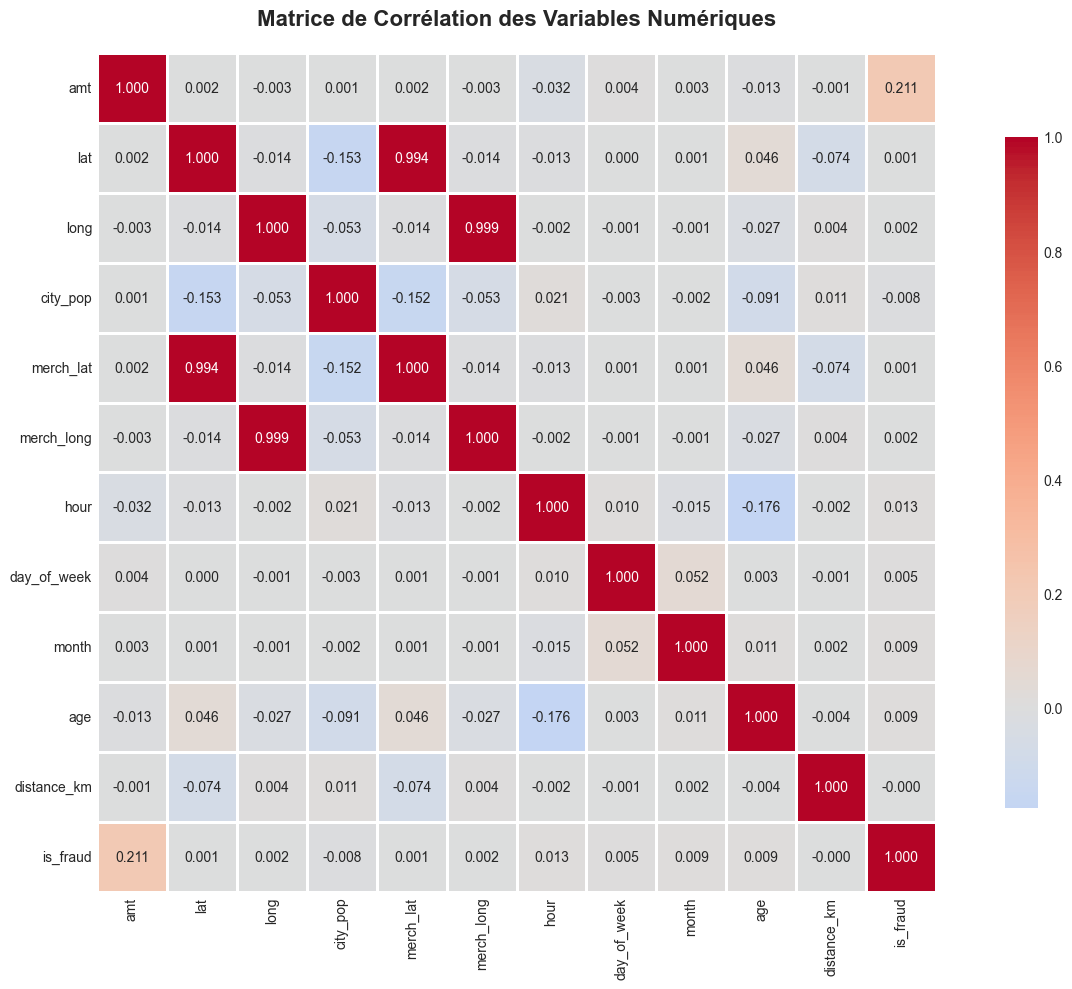

In [58]:
# Visualisation de la matrice de corrélation
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation des Variables Numériques', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('./png/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

#### 13. ANALYSE AVANCÉE - PATTERNS DE FRAUDE

In [59]:
# Transactions répétées sur même carte
print("Analyse des cartes avec fraudes multiples:")

card_fraud_counts = df[df['is_fraud'] == 1].groupby('cc_num').size()
multiple_fraud_cards = card_fraud_counts[card_fraud_counts > 1]
print(f"Nombre de cartes avec fraudes multiples: {len(multiple_fraud_cards)}")
if len(multiple_fraud_cards) > 0:
    print(f"Maximum de fraudes par carte: {multiple_fraud_cards.max()}")
    print(f"Moyenne de fraudes par carte frauduleuse: {multiple_fraud_cards.mean():.2f}")


Analyse des cartes avec fraudes multiples:
Nombre de cartes avec fraudes multiples: 141
Maximum de fraudes par carte: 16
Moyenne de fraudes par carte frauduleuse: 9.77


In [60]:
# Transactions par week-end vs semaine

print("Fraudes - Week-end vs Semaine:")

weekend_fraud = df.groupby('is_weekend')['is_fraud'].agg(['sum', 'count', 'mean'])
weekend_fraud['fraud_rate'] = weekend_fraud['mean'] * 100
weekend_fraud.index = ['Semaine', 'Week-end']
print(weekend_fraud)

Fraudes - Week-end vs Semaine:
          sum   count      mean  fraud_rate
Semaine   973  212897  0.004570    0.457029
Week-end  404   87103  0.004638    0.463819


In [61]:
# Top commerçants avec le plus de fraudes

print("Top 10 commerçants avec le plus de fraudes:")

merchant_fraud = df[df['is_fraud'] == 1].groupby('merchant').size().sort_values(ascending=False)
print(merchant_fraud.head(10))

Top 10 commerçants avec le plus de fraudes:
merchant
fraud_Mosciski, Ziemann and Farrell           15
fraud_Bashirian Group                         12
fraud_Cole PLC                                12
fraud_Heathcote, Yost and Kertzmann           12
fraud_Schultz, Simonis and Little             12
fraud_Kilback LLC                             12
fraud_Heathcote LLC                           11
fraud_Miller-Hauck                            11
fraud_Romaguera, Cruickshank and Greenholt    10
fraud_Lemke-Gutmann                           10
dtype: int64


In [62]:
# Analyse croisée: Catégorie × Période

print("Analyse croisée: Catégorie × Période de la journée:")

cross_analysis = pd.crosstab(df['category'], df['time_period'], 
                              values=df['is_fraud'], aggfunc='mean') * 100
cross_analysis

Analyse croisée: Catégorie × Période de la journée:


time_period,Après-midi (12h-18h),Matin (6h-12h),Nuit (0h-6h),Soirée (18h-24h)
category,,,,
entertainment,0.022681,0.052798,0.631912,0.344330
food_dining,0.031463,0.168776,0.675105,0.305424
gas_transport,NaN,0.065833,0.476719,NaN
grocery_net,NaN,0.038640,0.443160,NaN
grocery_pos,0.364964,0.184764,1.610108,15.576324
health_fitness,0.040008,NaN,NaN,0.366823
home,0.042860,NaN,NaN,0.250483
kids_pets,0.030089,NaN,NaN,0.299908
misc_net,0.564175,0.085911,0.731748,7.275132


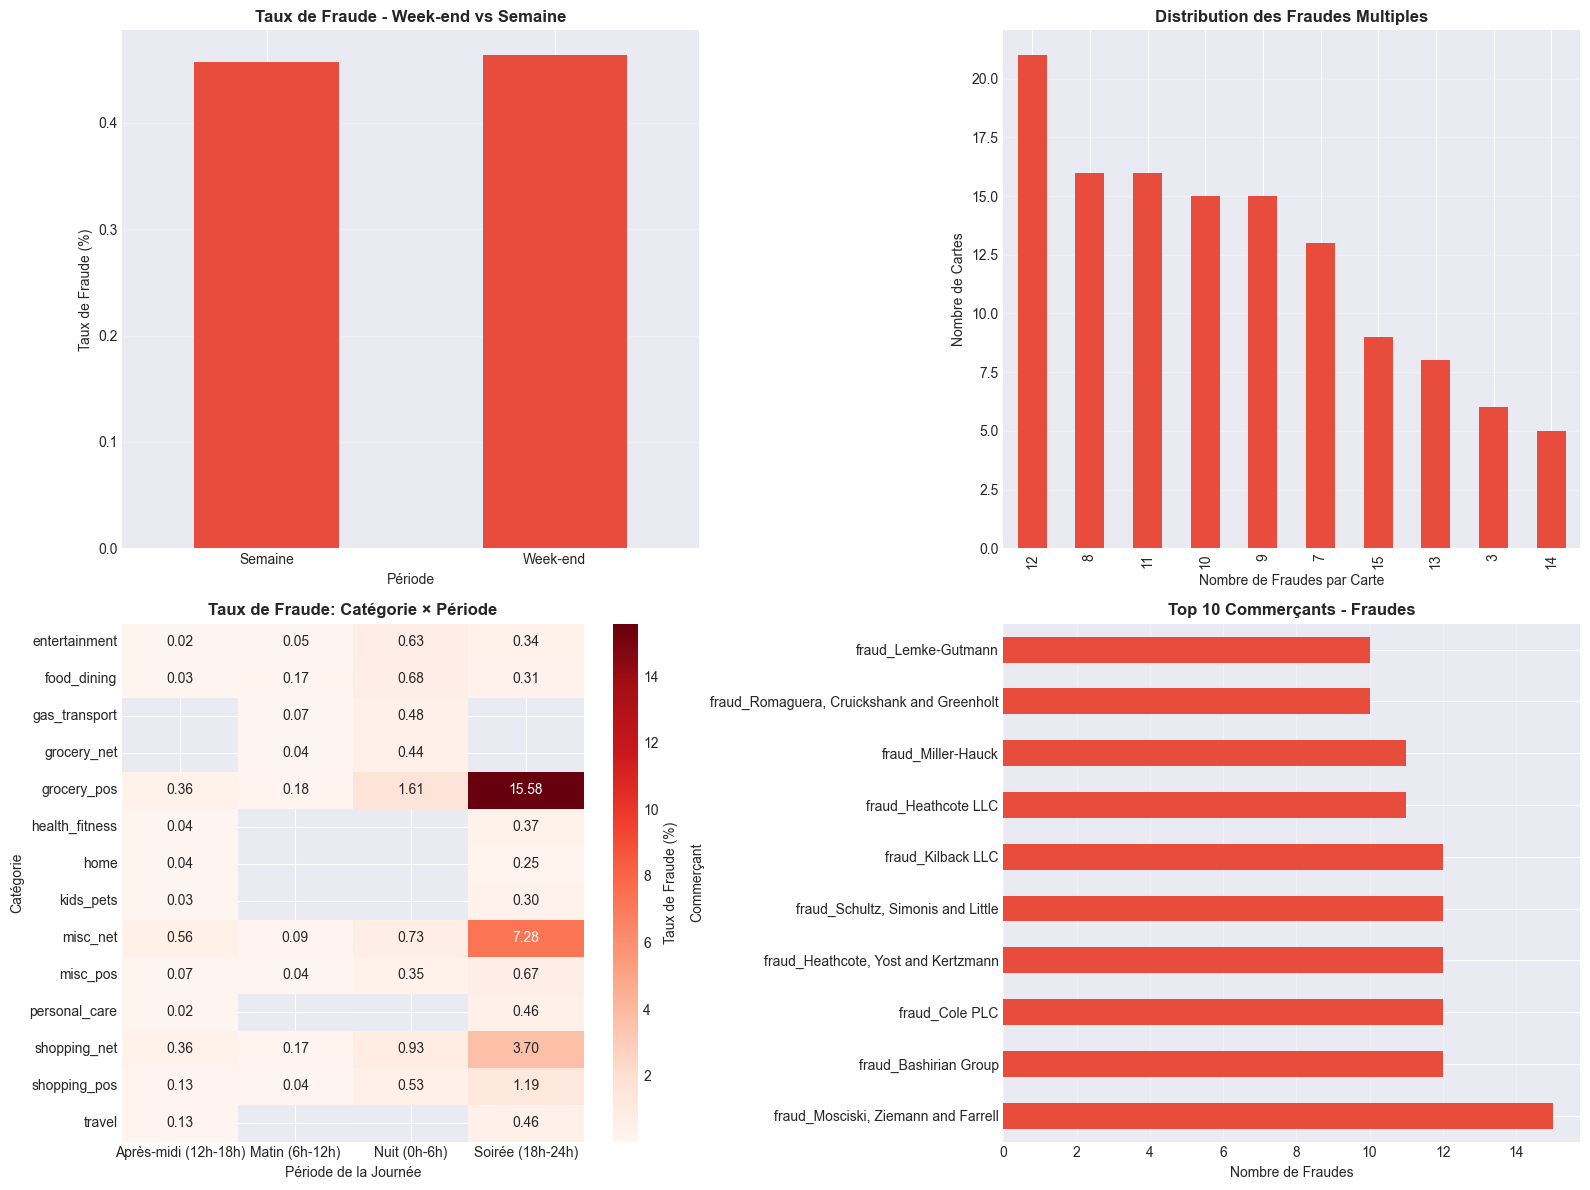

In [63]:
# Visualisation des patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Week-end vs Semaine
weekend_fraud['fraud_rate'].plot(kind='bar', ax=axes[0, 0], color='#e74c3c')
axes[0, 0].set_xlabel('Période')
axes[0, 0].set_ylabel('Taux de Fraude (%)')
axes[0, 0].set_title('Taux de Fraude - Week-end vs Semaine', fontweight='bold')
axes[0, 0].set_xticklabels(['Semaine', 'Week-end'], rotation=0)
axes[0, 0].grid(axis='y', alpha=0.3)

# Distribution des cartes avec fraudes multiples
if len(multiple_fraud_cards) > 0:
    multiple_fraud_cards.value_counts().head(10).plot(kind='bar', ax=axes[0, 1], color='#e74c3c')
    axes[0, 1].set_xlabel('Nombre de Fraudes par Carte')
    axes[0, 1].set_ylabel('Nombre de Cartes')
    axes[0, 1].set_title('Distribution des Fraudes Multiples', fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)

# Heatmap: Catégorie × Période
sns.heatmap(cross_analysis, annot=True, fmt='.2f', cmap='Reds', ax=axes[1, 0], 
            cbar_kws={'label': 'Taux de Fraude (%)'})
axes[1, 0].set_title('Taux de Fraude: Catégorie × Période', fontweight='bold')
axes[1, 0].set_xlabel('Période de la Journée')
axes[1, 0].set_ylabel('Catégorie')

# Top commerçants frauduleux
merchant_fraud.head(10).plot(kind='barh', ax=axes[1, 1], color='#e74c3c')
axes[1, 1].set_xlabel('Nombre de Fraudes')
axes[1, 1].set_ylabel('Commerçant')
axes[1, 1].set_title('Top 10 Commerçants - Fraudes', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./png/fraud_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

#### 14. RÉSUMÉ ET CONCLUSIONS

In [64]:
print("\n📊 RÉSUMÉ EXÉCUTIF - DÉTECTION DE FRAUDE BANCAIRE")


print(f"\n1. APERÇU DU DATASET:")
print(f"   • Total transactions: {len(df):,}")
print(f"   • Transactions frauduleuses: {df['is_fraud'].sum():,} ({df['is_fraud'].mean()*100:.2f}%)")
print(f"   • Transactions légitimes: {len(df) - df['is_fraud'].sum():,}")
print(f"   • Période couverte: {df['trans_date_trans_time'].min()} à {df['trans_date_trans_time'].max()}")

print(f"\n2. INSIGHTS FINANCIERS:")
print(f"   • Montant moyen transaction légitime: ${df[df['is_fraud']==0]['amt'].mean():.2f}")
print(f"   • Montant moyen transaction frauduleuse: ${df[df['is_fraud']==1]['amt'].mean():.2f}")
print(f"   • Montant total pertes par fraude: ${df[df['is_fraud']==1]['amt'].sum():,.2f}")

print(f"\n3. PATTERNS TEMPORELS CLÉS:")
top_hour = hourly_fraud['fraud_rate'].idxmax()
print(f"   • Heure la plus risquée: {top_hour}h (taux: {hourly_fraud.loc[top_hour, 'fraud_rate']:.2f}%)")
top_period = period_fraud['fraud_rate'].idxmax()
print(f"   • Période la plus risquée: {top_period}")
print(f"   • Différence week-end/semaine: {'Oui' if abs(weekend_fraud.loc['Week-end', 'fraud_rate'] - weekend_fraud.loc['Semaine', 'fraud_rate']) > 0.1 else 'Non significative'}")

print(f"\n4. CATÉGORIES À RISQUE:")
for idx, (cat, row) in enumerate(category_fraud.head(3).iterrows(), 1):
    print(f"   {idx}. {cat}: {row['fraud_rate']:.2f}% de fraude")

print(f"\n5. INSIGHTS GÉOGRAPHIQUES:")
top_state = state_fraud['fraud_rate'].idxmax()
print(f"   • État le plus risqué: {top_state} ({state_fraud.loc[top_state, 'fraud_rate']:.2f}%)")
print(f"   • Distance moyenne fraude: {df[df['is_fraud']==1]['distance_km'].mean():.1f} km")
print(f"   • Distance moyenne légitime: {df[df['is_fraud']==0]['distance_km'].mean():.1f} km")

print(f"\n6. PROFIL DÉMOGRAPHIQUE:")
if gender_fraud['fraud_rate'].max() - gender_fraud['fraud_rate'].min() > 0.05:
    risky_gender = gender_fraud['fraud_rate'].idxmax()
    print(f"   • Genre plus à risque: {risky_gender}")
else:
    print(f"   • Pas de différence significative par genre")
risky_age = age_fraud['fraud_rate'].idxmax()
print(f"   • Catégorie d'âge plus à risque: {risky_age}")

print("\n7. RECOMMANDATIONS POUR LA MODÉLISATION:")
print("   ✅ Variables importantes à inclure:")
print("      • Montant de la transaction (amt)")
print("      • Heure et période de la journée")
print("      • Catégorie du commerçant")
print("      • Distance client-commerçant")
print("      • Localisation géographique (état)")
print("      • Âge du client")
print("\n   ⚠️  Points d'attention:")
print("      • Dataset fortement déséquilibré → Utiliser SMOTE/sous-échantillonnage")
print("      • Importance du feature engineering temporel")
print("      • Considérer les interactions entre variables")
print("      • Valider sur période temporelle séparée")

print("\n8. PROCHAINES ÉTAPES:")
print("   1. Feature engineering avancé (agrégations, interactions)")
print("   2. Sélection de features (importance, corrélations)")
print("   3. Traitement du déséquilibre des classes")
print("   4. Entraînement de modèles (Random Forest, XGBoost, Neural Networks)")
print("   5. Optimisation des hyperparamètres")
print("   6. Évaluation (Precision, Recall, F1-Score, AUC-ROC)")
print("   7. Analyse des erreurs et amélioration itérative")

print("\n" + "=" * 80)
print("FIN DE L'ANALYSE EXPLORATOIRE")
print("=" * 80)
print("\n💾 Fichiers générés:")
print("   • fraud_distribution.png")
print("   • amount_analysis.png")
print("   • temporal_analysis.png")
print("   • category_analysis.png")
print("   • geographic_analysis.png")
print("   • demographic_analysis.png")
print("   • correlation_matrix.png")
print("   • fraud_patterns.png")
print("\n✅ Analyse terminée avec succès!")


📊 RÉSUMÉ EXÉCUTIF - DÉTECTION DE FRAUDE BANCAIRE

1. APERÇU DU DATASET:
   • Total transactions: 300,000
   • Transactions frauduleuses: 1,377 (0.46%)
   • Transactions légitimes: 298,623
   • Période couverte: 2020-06-21 12:14:25 à 2020-10-12 14:06:30

2. INSIGHTS FINANCIERS:
   • Montant moyen transaction légitime: $67.43
   • Montant moyen transaction frauduleuse: $529.17
   • Montant total pertes par fraude: $728,672.55

3. PATTERNS TEMPORELS CLÉS:
   • Heure la plus risquée: 22h (taux: 2.32%)
   • Période la plus risquée: Soirée (18h-24h)
   • Différence week-end/semaine: Non significative

4. CATÉGORIES À RISQUE:
   1. shopping_net: 1.43% de fraude
   2. misc_net: 1.13% de fraude
   3. grocery_pos: 1.05% de fraude

5. INSIGHTS GÉOGRAPHIQUES:
   • État le plus risqué: HI (1.54%)
   • Distance moyenne fraude: 76.0 km
   • Distance moyenne légitime: 76.1 km

6. PROFIL DÉMOGRAPHIQUE:
   • Pas de différence significative par genre
   • Catégorie d'âge plus à risque: 55-65 ans

7. REC